In [1]:
import pandas as pd
import joblib

from sklearn.preprocessing import StandardScaler

In [2]:
train_df = pd.read_csv(
    r"E:\Hybrid_IDS_Project\dataset\processed\train_without_unknown.csv"
)

train_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


Separate Features and Labels

In [3]:
X_train = train_df.drop("Label", axis=1)
y_train = train_df["Label"]

print(X_train.shape)
print(y_train.shape)

(2508237, 78)
(2508237,)


Fit the StandardScaler

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

print("Scaler created successfully!")

Scaler created successfully!


In [5]:
joblib.dump(
    scaler,
    r"E:\Hybrid_IDS_Project\dataset\models\scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [6]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

load test data

In [7]:
test_df = pd.read_csv(
    r"E:\Hybrid_IDS_Project\dataset\processed\unknown_test.csv"
)

X_test = test_df.drop("Label", axis=1)
y_test = test_df["Label"]

In [8]:
scaler = joblib.load(
    r"E:\Hybrid_IDS_Project\dataset\models\scaler.pkl"
)

X_test_scaled = scaler.transform(X_test)

Load all Models

In [9]:
rf = joblib.load(
    r"E:\Hybrid_IDS_Project\dataset\models\random_forest_unknown.pkl"
)

ocsvm = joblib.load(
    r"E:\Hybrid_IDS_Project\dataset\models\ocsvm_unknown.pkl"
)

lof = joblib.load(
    r"E:\Hybrid_IDS_Project\dataset\models\lof.pkl"
)

cnn = load_model(
    r"E:\Hybrid_IDS_Project\dataset\models\cnn_unknown.keras"
)

mlp = load_model(
    r"E:\Hybrid_IDS_Project\dataset\models\best_mlp.keras"
)

Get Prediction Scores

In [10]:
# Random Forest
rf_scores = rf.predict_proba(X_test)[:, 1]

# CNN
X_test_cnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

cnn_scores = cnn.predict(X_test_cnn).ravel()

# MLP
mlp_scores = mlp.predict(X_test_scaled).ravel()

# OCSVM
ocsvm_scores = -ocsvm.decision_function(X_test_scaled)

# LOF
lof_scores = -lof.decision_function(X_test_scaled)

e:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
786/786 ━━━━━━━━━━━━━━━━━━━━ 1s 788us/step


Roc Curve

In [14]:
test_df = pd.read_csv(
    r"E:\Hybrid_IDS_Project\dataset\processed\unknown_test.csv"
)

X_test = test_df.drop("Label", axis=1)

# Convert to binary labels
y_test = test_df["Label"].apply(
    lambda x: 0 if x == "BENIGN" else 1
)

print(y_test.value_counts())

Label
1    12561
0    12561
Name: count, dtype: int64


In [15]:
print(y_test.unique())

[1 0]


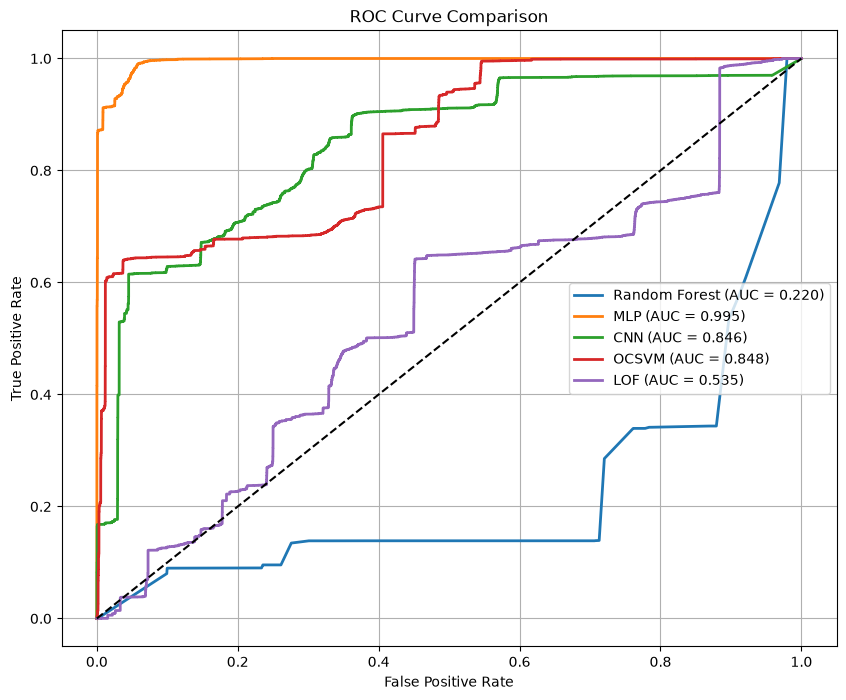

In [16]:
plt.figure(figsize=(10,8))

models = {
    "Random Forest": rf_scores,
    "MLP": mlp_scores,
    "CNN": cnn_scores,
    "OCSVM": ocsvm_scores,
    "LOF": lof_scores
}

auc_results = {}

for name, scores in models.items():

    fpr, tpr, _ = roc_curve(y_test, scores)

    roc_auc = auc(fpr, tpr)

    auc_results[name] = roc_auc

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.savefig(
    r"E:\Hybrid_IDS_Project\dataset\results\ROC_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
rf_probs = rf.predict_proba(X_test)

print(rf.classes_)
print(rf_probs[:5])

[0 1]
[[0.52 0.48]
 [0.82 0.18]
 [0.5  0.5 ]
 [0.72 0.28]
 [0.5  0.5 ]]


e:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [18]:
print(type(X_test))
print(type(X_test_scaled))

<class 'pandas.DataFrame'>
<class 'numpy.ndarray'>


In [19]:
rf_scores1 = rf.predict_proba(X_test)[:,1]

e:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [20]:
rf_scores2 = rf.predict_proba(X_test_scaled)[:,1]

In [21]:
print(rf_scores1[:10])
print(rf_scores2[:10])

[0.48 0.18 0.5  0.28 0.5  0.28 0.5  0.5  0.28 0.28]
[0.         0.08       0.0200039  0.06008547 0.0200039  0.06008547
 0.0200039  0.02000028 0.06008547 0.06008547]
